In [2]:
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('placement.csv')

In [1]:
df.head()

NameError: name 'df' is not defined

In [5]:
df=df.iloc[:,1:]

In [6]:
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


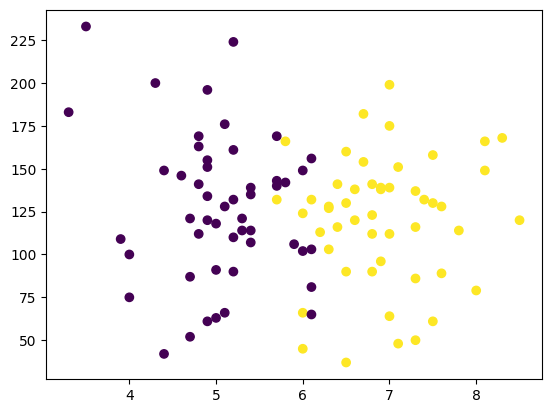

In [34]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [11]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [9]:
from sklearn.model_selection import train_test_split

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [14]:
x_train

,cgpa,iq
58,8.0,79.0
22,4.9,120.0
78,6.1,81.0
20,6.6,120.0
24,4.7,121.0
...,...,...
30,7.6,128.0
21,7.1,151.0
94,4.7,52.0
13,6.4,116.0


In [15]:
y_train

58    1
22    0
78    0
20    1
24    0
     ..
30    1
21    1
94    0
13    1
40    0
Name: placement, Length: 80, dtype: int64

In [18]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [23]:
x_train_scaled

array([[ 1.7951053 , -1.11730975],
       [-0.92774555, -0.11216   ],
       [ 0.12626123, -1.06827806],
       [ 0.56543072, -0.11216   ],
       [-1.10341335, -0.08764415],
       [ 0.47759682, -0.84763543],
       [ 0.82893242,  0.3536411 ],
       [ 0.03842733, -0.01409661],
       [ 2.23427479, -0.11216   ],
       [-2.15742013,  2.65813077],
       [ 0.03842733, -1.95084857],
       [ 1.44376971, -0.87215128],
       [-1.71825064, -0.60247695],
       [ 0.03842733,  0.59879958],
       [ 0.91676632,  1.23621161],
       [-0.75207776, -1.43601577],
       [ 1.35593581,  0.8194422 ],
       [ 1.8829392 ,  1.01556898],
       [-1.71825064, -1.21537314],
       [ 2.058607  ,  1.06460068],
       [-1.36691504,  0.59879958],
       [-0.66424386,  0.89298975],
       [ 1.26810191,  0.18203017],
       [ 0.12626123,  0.18203017],
       [-0.22507436,  1.08911653],
       [-1.01557945, -0.30828678],
       [-0.22507436,  0.37815695],
       [ 1.18026801,  0.30460941],
       [ 0.74109852,

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
model=LogisticRegression()

In [26]:
model.fit(x_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [29]:
y_pred=model.predict(x_test_scaled)

In [31]:
from sklearn.metrics import accuracy_score

In [32]:
accuracy_score(y_pred,y_test)

0.95

<Axes: >

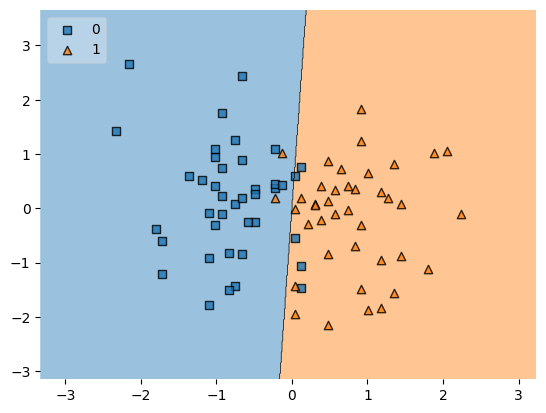

In [39]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(x_train_scaled, y_train.values, clf=model, legend=2)